In [298]:
from sage.graphs.graph import Graph

GDB = Graph([(1,2), (1,17), (1,10), (1,11), (2,3), (3,4), (3, 6), (4,5), (4,7), (5,6), (6,7), (7,8), (8,17), (1,9), (9,17),
          (10,12), (11,12), (11,13), (11, 14), (12,15), (12,16), (12,17), (13,15), (14,15), (15,16), (16,17)])

GBrown = Graph({1: [2,4], 2: [3], 3: [4,5,6,8,9], 4: [5,7], 6: [7,8], 7: [8], 8: [9]}) 
G = GBrown.copy()
G2 = GDB.copy()
#G.show()
#G2.show()

In [299]:
from sage.graphs.connectivity import spqr_tree, spqr_tree_to_graph

T = spqr_tree(GDB)
TG = spqr_tree_to_graph(T)

In [360]:
def find_split_components(G, i, components):
    #print(G.edges())
    if G.num_verts() == 1:
        return (G, i)
    if G.num_verts() == 2 and G.size() >= 1:
        return (G, i)
    if G.num_verts() == 3 and G.triangles_count() == 1:
        return (G, i)

    for g in G.vertices():
        for h in G.vertices():
            if g == h:
                continue

            T = G.copy()  
            if T.has_vertex(g):
                T.delete_vertex(g)
            if T.has_vertex(h):
                T.delete_vertex(h)

            if not T.is_connected():
                #print("splitting on: " + str(g) +", " + str(h))
                print("split on " + str(g) + " " + str(h))
                subgraphs = [c.copy() for c in T.connected_components_subgraphs()]
                if {g, h} in [set(edge[:2]) for edge in G.edges()]:
                    pG = Graph([])
                    #print("INSIDE")
                    for sg in subgraphs:
                        pG.add_edge(g, h, "virtual" + str(i))
                        i = i + 1
                    components.append(pG)
                    for sg in subgraphs:
                        i = i - 1     

                for c in subgraphs:
                    c.add_vertices([g, h])
                    for v in c.vertices():
                        if G.has_edge(g, v):
                            label = G.edge_label(g, v)
                            c.add_edge(g, v, label)
                        if G.has_edge(h, v):
                            label = G.edge_label(h, v)
                            c.add_edge(h, v, label)
                    c.add_edge(g, h, 'virtual ' + str(i))
                    #c.show()
                    #print(c.edges())

                #G.show()

                i = i + 1
                for c in subgraphs:
                    ret = find_split_components(c, i, components)
                    if ret is not None:
                        components.append(ret[0])
                        i = ret[1]

                return components

    return (G, i) 

    

In [361]:
components = find_split_components(G, 0, [])
for i, comp in enumerate(components):
    print(f"Component {i+1}:")
    print(f"  Vertices: {comp.vertices()}")
    print(f"  Edges: {comp.edges()}")
    print()

split on 1 3
split on 3 4
split on 3 7
split on 3 8
Component 1:
  Vertices: [3, 4]
  Edges: [(3, 4, 'virtual3')]

Component 2:
  Vertices: [3, 8]
  Edges: [(3, 8, 'virtual4')]

Component 3:
  Vertices: [3, 6, 7, 8]
  Edges: [(3, 6, None), (3, 7, 'virtual 2'), (3, 8, 'virtual 3'), (6, 7, None), (6, 8, None), (7, 8, None)]

Component 4:
  Vertices: [3, 8, 9]
  Edges: [(3, 8, 'virtual 3'), (3, 9, None), (8, 9, None)]

Component 5:
  Vertices: [3, 4]
  Edges: [(3, 4, 'virtual3')]

Component 6:
  Vertices: [3, 4, 7]
  Edges: [(3, 4, 'virtual 1'), (3, 7, 'virtual 2'), (4, 7, None)]

Component 7:
  Vertices: [3, 4]
  Edges: [(3, 4, 'virtual3')]

Component 8:
  Vertices: [1, 3, 4]
  Edges: [(1, 3, 'virtual 0'), (1, 4, None), (3, 4, 'virtual 1')]

Component 9:
  Vertices: [3, 4, 5]
  Edges: [(3, 4, 'virtual 1'), (3, 5, None), (4, 5, None)]

Component 10:
  Vertices: [3, 4]
  Edges: [(3, 4, 'virtual3')]

Component 11:
  Vertices: [1, 2, 3]
  Edges: [(1, 2, None), (1, 3, 'virtual 0'), (2, 3, Non

In [364]:
def get_labels(G):
    return set(label for _, _, label in G.edges() if label is not None)

def is_cycle_graph(G):
    return G.is_connected() and G.num_verts() == G.num_edges() and all(d == 2 for d in G.degree())

def merge_graphs_on_shared_edge(G1, G2, v, w):
    merged = G1.copy()

    for vert in G2.vertices():
        if vert not in merged:
            merged.add_vertex(vert)

    for e in G2.edges():
        u, x, label = e  
        if merged.has_edge(u, x):
            old_label = merged.edge_label(u, x)
            if old_label != label:
                if old_label is None:
                    merged.set_edge_label(u, x, label)
                elif label is None:
                    pass
                else:
                    merged.set_edge_label(u, x, (old_label, label))
        else:
            merged.add_edge(u, x, label)
            merged.delete_edge(v,w)

    return merged


    
def merge_split_components(components):
    for c1 in components:
        for c2 in components:
            if c1 == c2:
                continue
            labels_c1 = c1.edge_labels()
            labels_c2 = c2.edge_labels()

            common_label = set(labels_c1) & set(labels_c2)
            common_label.discard(None)


            if common_label:
                print("Shared label:", common_label)
                if is_cycle_graph(c1) and is_cycle_graph(c2):
                     for label in common_label:
                        edge_c1 = next((e for e in c1.edges(labels=True) if e[2] == label), None)
                        edge_c2 = next((e for e in c2.edges(labels=True) if e[2] == label), None)
    
                        if edge_c1 and edge_c2:
                            v, w = edge_c1[0], edge_c1[1] 
                            merged = merge_graphs_on_shared_edge(c1, c2, v, w)
                            merged.show()

        

Shared label: {'virtual 3'}
Shared label: {'virtual 2'}
Shared label: {'virtual 3'}
Shared label: {'virtual 2'}
Shared label: {'virtual 1'}


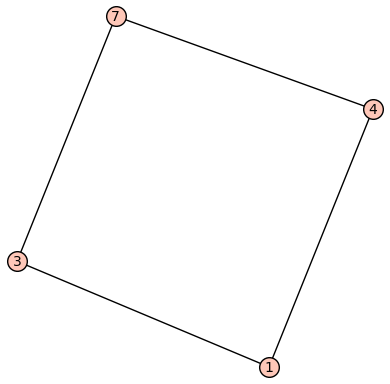

Shared label: {'virtual 1'}


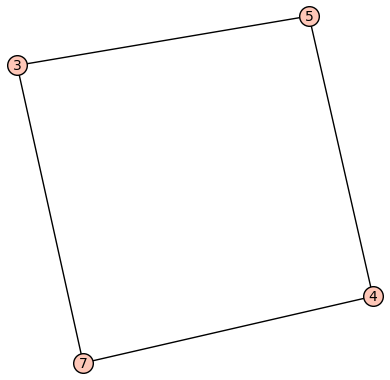

Shared label: {'virtual 1'}


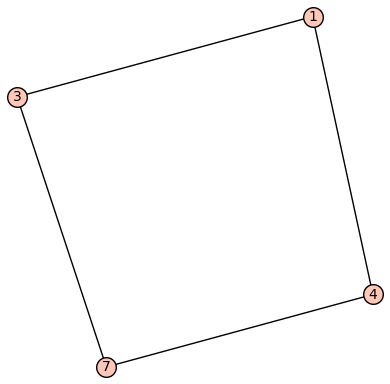

Shared label: {'virtual 1'}


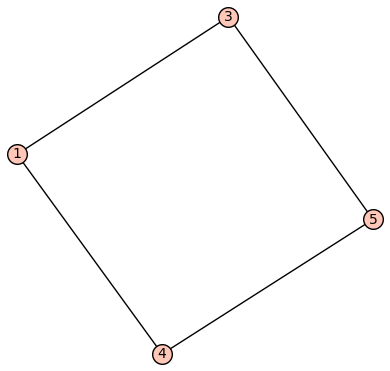

Shared label: {'virtual 0'}


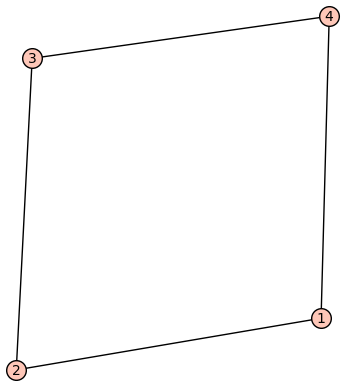

Shared label: {'virtual 1'}


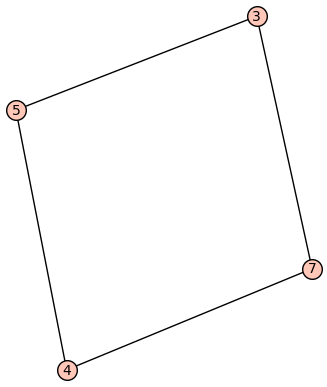

Shared label: {'virtual 1'}


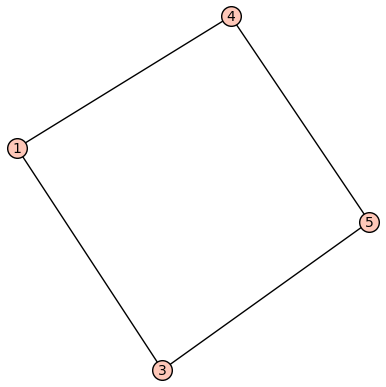

Shared label: {'virtual 0'}


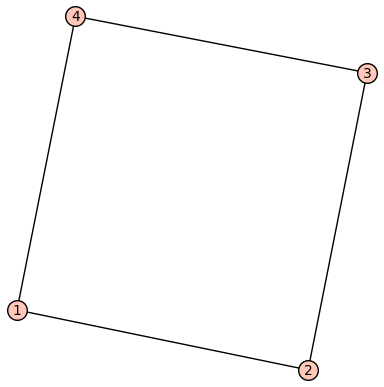

In [365]:
merge_split_components(components)